 # SARIMAX — Predicción de consumo mensual del Metro de Medellín



 1. **Búsqueda de hiperparámetros guiada** (no grid search a ciegas): parte del **mejor SARIMAX

    conocido** (`SARIMAX_BEST_KNOWN`: `order=(3,0,0)`, `seasonal_order=(1,0,2,7)`, MAPE CV ≈ 4.242 %)

    y refina su **vecindario** con **Optuna (TPE)**, encolando ese punto como primer trial — de

    modo que el resultado **nunca empeora** el punto de partida.

 2. El eje de comparación de todo el notebook es **default vs tuneado**.

 3. Los splits por fechas, el walk-forward CV mensual, las métricas MAE/RMSE/MAPE/R², el manejo de

    meses atípicos, los intervalos y la exportación siguen **exactamente** el mismo criterio que el

    notebook de Random Forest, para que ambos sean directamente comparables.

 4. La **importancia de variables exógenas** se corrige: ya no se asume que los coeficientes exógenos

    ocupan las últimas posiciones del vector de parámetros (cálculo roto anterior); ahora se extraen

    por **nombre** desde el objeto ajustado, y se añade una importancia por **permutación**

    (out-of-sample) como complemento — el mismo criterio que usa el notebook de árboles.



 ## 0. Setup (Colab)



 Optuna y pmdarima no vienen preinstalados en Colab. Esta celda los instala en el kernel actual

 de forma idempotente; si ya están instalados, no hace nada.

In [ ]:
# Colab: instalar Optuna y pmdarima para la búsqueda guiada (idempotente)
%pip install optuna pmdarima


 ## 1. Imports

In [4]:
import re, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pandas.tseries.offsets import MonthBegin, MonthEnd
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/EAFIT/SIMAT/Metro/data/

# ── Suprimir warnings de convergencia limpiamente ─────────────────────────────
warnings.filterwarnings('ignore')
try:
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
except ImportError:
    pass

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

# pmdarima para ajustar SARIMAX con variables exógenas
try:
    from pmdarima import ARIMA as PmARIMA
    HAS_PMDARIMA = True
    print(f"✓ pmdarima disponible")
except ImportError:
    HAS_PMDARIMA = False
    print("✗ pmdarima no instalado — ejecutar: pip install pmdarima")

# Optuna para la búsqueda guiada (warm-started). Si no está, se usa un fallback local.
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f"✓ Optuna {optuna.__version__}")
except ImportError:
    HAS_OPTUNA = False
    print("✗ Optuna no instalado — se usará búsqueda local (fallback). Instalar: pip install optuna")

try:
    from tqdm.auto import tqdm; HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    class tqdm:
        def __init__(self, iterable=None, **kw): self._it = iterable or []
        def __iter__(self): return iter(self._it)
        def set_postfix(self, **kw): pass

print("✓ Librerías base listas (SARIMAX)")



✓ pmdarima disponible
✓ Optuna 4.9.0
✓ Librerías base listas (SARIMAX)


 ## 2. Configuración global



 **Ajusta aquí las fechas, los meses atípicos, los parámetros de la búsqueda y el punto de partida

 del tuning.**



| Parámetro | Descripción |
|-----------|-------------|
| `TRAIN_START` / `TEST_START` | Fechas de los splits (alineadas con SARIMAX). Test = **un año** (2025). |
| `N_CV_FOLDS` | Meses de walk-forward CV (**un año de validación**) para evaluar cada configuración. Los atípicos se saltan. |
| `N_TRIALS` | Iteraciones de la búsqueda guiada (warm-started desde `RF_BEST_KNOWN`) |
| `SEARCH_N_ESTIMATORS` / `FINAL_N_ESTIMATORS` | Árboles **durante la búsqueda** (pocos, rápido) vs **del modelo final** (todos). El nº de árboles casi no cambia el ranking de estructura, así que buscar con pocos y reentrenar con todos acelera sin perder rigor. |
| `CI_LEVEL` | Nivel de confianza de los intervalos |
| `RF_BEST_KNOWN` | Mejor RF hallado en el notebook de árboles — punto de partida de la búsqueda |
| `DEFAULT_RF` | Baseline por defecto (para el contraste *default vs tuneado*) |



In [12]:
# ─── AJUSTA AQUÍ ────────────────────────────────────────────────────────────
CSV_PATH    = 'data//features_sin_lags_limpio_new.csv'   # mismo espíritu de archivo que la familia RF / árboles

TRAIN_START = '2018-01'   # Primer mes del train
TEST_START  = '2025-01'   # Primer mes del test  →  test = un año (2025-01 … 2025-12)

N_CV_FOLDS  = 12          # Folds walk-forward de VALIDACIÓN (un año) para evaluar cada config
N_TRIALS    = 15          # Iteraciones de la búsqueda guiada (warm-start incluido)
SEED        = 42
CI_LEVEL    = 0.90        # Nivel de confianza de los intervalos (MAPE mensual y bandas)
SEASONAL_M  = 7           # Periodicidad estacional: 7 = semanal

# Meses atípicos  ->  EXCLUIDOS de todos los promedios / análisis agregado (incluido el CV)
ATYPICAL_MONTHS = ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']
SHOW_ALL_MONTHS_IN_PLOTS = True

# ── Mejor SARIMAX hallado hasta ahora (MAPE CV ≈ 4.242 %) ───────────────────
#    La búsqueda guiada parte de esta ESTRUCTURA y refina su vecindario.
BEST_KNOWN_SARIMAX = dict(order=(3, 0, 0), seasonal_order=(1, 0, 2, SEASONAL_M))

# Baseline por defecto (para el contraste default vs tuned)
DEFAULT_SARIMAX = dict(order=(2, 1, 2), seasonal_order=(1, 0, 1, SEASONAL_M))
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)

# Esquema de color: contraste DEFAULT vs TUNED (mismo criterio que el notebook de RF)
VARIANTS = ['default', 'tuned']
VCOLORS  = {'default': '#90A4AE', 'tuned': '#388E3C'}   # gris vs verde
SARIMAX_COLOR  = '#388E3C'
COLOR_ATYPICAL = '#6A1B9A'   # morado — meses atípicos

def is_atyp(mes):
    return mes in ATYPICAL_MONTHS

print("Modelo          : SARIMAX (único)")
print(f"Train desde     : {TRAIN_START}")
print(f"Test desde      : {TEST_START}  (un año → hasta fin de datos)")
print(f"Folds CV        : {N_CV_FOLDS}  (un año de validación; atípicos excluidos)")
print(f"Trials búsqueda : {N_TRIALS}  (warm-start desde SARIMAX_BEST_KNOWN)")
print(f"Estacionalidad  : m={SEASONAL_M}")
print(f"Meses atípicos  : {ATYPICAL_MONTHS}")
print(f"Best-known      : {BEST_KNOWN_SARIMAX}")



Modelo          : SARIMAX (único)
Train desde     : 2018-01
Test desde      : 2025-01  (un año → hasta fin de datos)
Folds CV        : 12  (un año de validación; atípicos excluidos)
Trials búsqueda : 15  (warm-start desde SARIMAX_BEST_KNOWN)
Estacionalidad  : m=7
Meses atípicos  : ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']
Best-known      : {'order': (3, 0, 0), 'seasonal_order': (1, 0, 2, 7)}


 ## 3. Carga del dataset

> **Unidades.** `Consumo` está en **kWh de energía diaria** (suma de las 24 lecturas horarias del día).
> La anotación *"Nivel de Tensión (kV): 57,50 ≤ x < 220,00 (Nivel IV)"* del origen de los datos **no es una unidad**:
> describe el **nivel de tensión** del punto de medida (categoría tarifaria CREG; Nivel IV = sub‑transmisión / alta
> tensión), normal para una carga grande como el Metro. No se aplica ninguna conversión — solo se homogenizan las
> etiquetas de los ejes a **kWh**.



In [13]:
df_raw = pd.read_csv(CSV_PATH)
df_raw['Fecha'] = pd.to_datetime(df_raw['Fecha'])
df_raw = df_raw.set_index('Fecha')
df_raw.sort_index(inplace=True)
df_raw = df_raw.asfreq('D')   # frecuencia diaria (calendario)

# Convertir booleanos a int para statsmodels
bool_cols = df_raw.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_raw[bool_cols] = df_raw[bool_cols].astype(int)

# Filtrar desde TRAIN_START (alineación con RF)
df = df_raw[df_raw.index >= pd.Timestamp(TRAIN_START + '-01')].copy()

print(f"Shape           : {df.shape}")
print(f"Rango de fechas : {df.index.min().date()} → {df.index.max().date()}")
nulos = df.isnull().sum()
nc = nulos[nulos > 0]
print(f"Columnas con nulos: {len(nc)}" + (f"\n{nc}" if len(nc) else " — ninguno"))
print(f"\nConsumo — media: {df['Consumo'].mean():,.0f}  "
      f"std: {df['Consumo'].std():,.0f}  "
      f"min: {df['Consumo'].min():,.0f}  max: {df['Consumo'].max():,.0f}")



Shape           : (2920, 28)
Rango de fechas : 2018-01-03 → 2025-12-31
Columnas con nulos: 0 — ninguno

Consumo — media: 69,262  std: 13,190  min: 19,741  max: 90,996


 ## 4. Variables exógenas



 SARIMAX solo debe recibir **variables exógenas verdaderas** (calendario + otras columnas que no dependen del propio `Consumo`). A diferencia del notebook de árboles, **no se usan `lag_k` ni columnas `rolling`** como exógenas: esas features están construidas a partir del propio target y filtrarlas evita fugas de información (*leakage*) hacia el modelo estadístico. Si el CSV no trae ese tipo de columnas (como es el caso del archivo por defecto), el filtro simplemente no elimina nada — pero se deja explícito por si se cambia de fuente de datos.



In [14]:
TARGET = 'Consumo'
_pat_lag = re.compile(r'^lag_(\d+)$')
_roll_prefixes = ('media_roll', 'std_roll', 'mediana_roll')
_sin_cos_ = ('_sin', '_cos')

_all_candidate_cols = [c for c in df.columns if c != TARGET]
_leaky_cols = [c for c in _all_candidate_cols
               if _pat_lag.match(c) or c.startswith(_roll_prefixes) or any(c.endswith(suffix) for suffix in _sin_cos_)]

EXOG_COLS = [c for c in _all_candidate_cols if c not in _leaky_cols]

print(f"Variable objetivo         : {TARGET}")
print(f"Columnas candidatas       : {len(_all_candidate_cols)}")
print(f"Excluidas (lag/rolling)   : {len(_leaky_cols)}" + (f" → {_leaky_cols}" if _leaky_cols else " — ninguna"))
print(f"Variables EXOG usadas ({len(EXOG_COLS)}): {EXOG_COLS}")

y_full = df[TARGET]
X_full = df[EXOG_COLS]

Variable objetivo         : Consumo
Columnas candidatas       : 27
Excluidas (lag/rolling)   : 16 → ['media_roll_7', 'std_roll_7', 'mediana_roll_7', 'media_roll_14', 'std_roll_14', 'mediana_roll_14', 'media_roll_28', 'std_roll_28', 'mediana_roll_28', 'media_roll_60', 'std_roll_60', 'mediana_roll_60', 'dow_sin', 'dow_cos', 'mes_sin', 'mes_cos']
Variables EXOG usadas (11): ['dia_semana', 'mes', 'año', 'semana_año', 'es_fin_semana', 'es_festivo', 'dia_antes_festivo', 'dia_despues_festivo', 'semana_navidad', 'covid_cuarentena', 'es_mantenimiento']


 ## 5. Definición dinámica de splits



- **Train**: desde `TRAIN_START` hasta el día anterior a `TEST_START` (ventana expandible en cada mes de test).
- **Test**: desde `TEST_START` hasta el final del dataset (meses con ≥ 20 días) → **un año** (2025).
- **Folds CV (validación)**: los `N_CV_FOLDS` meses previos al test, **saltando los `ATYPICAL_MONTHS`** y
  alcanzando más atrás si hace falta, para tener un **año completo de validación limpia**.
- **Meses estables**: los meses de test que **no** están en `ATYPICAL_MONTHS`. Todo el análisis
  agregado (promedios, comparaciones, conclusiones) se hace **solo sobre estos**.



In [15]:
def month_row_count(period):
    start = pd.Timestamp(str(period) + '-01')
    end   = start + MonthEnd(1)
    return len(df[(df.index >= start) & (df.index <= end)])

test_start = pd.Timestamp(TEST_START + '-01')

# ── Meses de test: desde TEST_START hasta fin, con ≥ 20 días ──────────────────
p = test_start.to_period('M')
last_period = df.index.max().to_period('M')
TEST_MONTHS = []
while p <= last_period:
    if month_row_count(p) >= 20:
        TEST_MONTHS.append(str(p))
    p += 1
if not TEST_MONTHS:
    raise ValueError(f"No hay meses completos de test desde {TEST_START}. Ajusta TEST_START.")

# ── Folds CV (N_CV_FOLDS meses antes del test, dentro del train, SALTANDO atípicos) ──
p = (test_start - MonthBegin(1)).to_period('M')
CV_MONTHS = []
while len(CV_MONTHS) < N_CV_FOLDS:
    mes = str(p)
    if month_row_count(p) >= 20 and mes not in ATYPICAL_MONTHS:
        CV_MONTHS.insert(0, mes)
    p -= 1

# ── Meses estables vs atípicos ────────────────────────────────────────────────
STABLE_MONTHS   = [m for m in TEST_MONTHS if m not in ATYPICAL_MONTHS]
ATYP_IN_TEST    = [m for m in TEST_MONTHS if m in ATYPICAL_MONTHS]
ANALYSIS_MONTHS = STABLE_MONTHS                                   # base de TODO promedio
PLOT_MONTHS     = TEST_MONTHS if SHOW_ALL_MONTHS_IN_PLOTS else STABLE_MONTHS

pre_test = df[df.index < test_start]

print("=" * 64)
print(f"  Dataset completo : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Train (pre-test) : {pre_test.index.min().date()} → {pre_test.index.max().date()}  ({len(pre_test)} días)")
print(f"  Folds CV ({len(CV_MONTHS)} m.) : {CV_MONTHS[0]} → {CV_MONTHS[-1]}  (dentro del train, atípicos saltados)")
print(f"  Test  ({len(TEST_MONTHS)} m.) : {TEST_MONTHS[0]} → {TEST_MONTHS[-1]}")
print(f"  → Estables ({len(STABLE_MONTHS)}) : {STABLE_MONTHS}")
print(f"  → Atípicos ({len(ATYP_IN_TEST)}) : {ATYP_IN_TEST}")
print("=" * 64)



  Dataset completo : 2018-01-03 → 2025-12-31
  Train (pre-test) : 2018-01-03 → 2024-12-31  (2555 días)
  Folds CV (12 m.) : 2024-01 → 2024-12  (dentro del train, atípicos saltados)
  Test  (12 m.) : 2025-01 → 2025-12
  → Estables (7) : ['2025-01', '2025-02', '2025-04', '2025-06', '2025-07', '2025-08', '2025-09']
  → Atípicos (5) : ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']


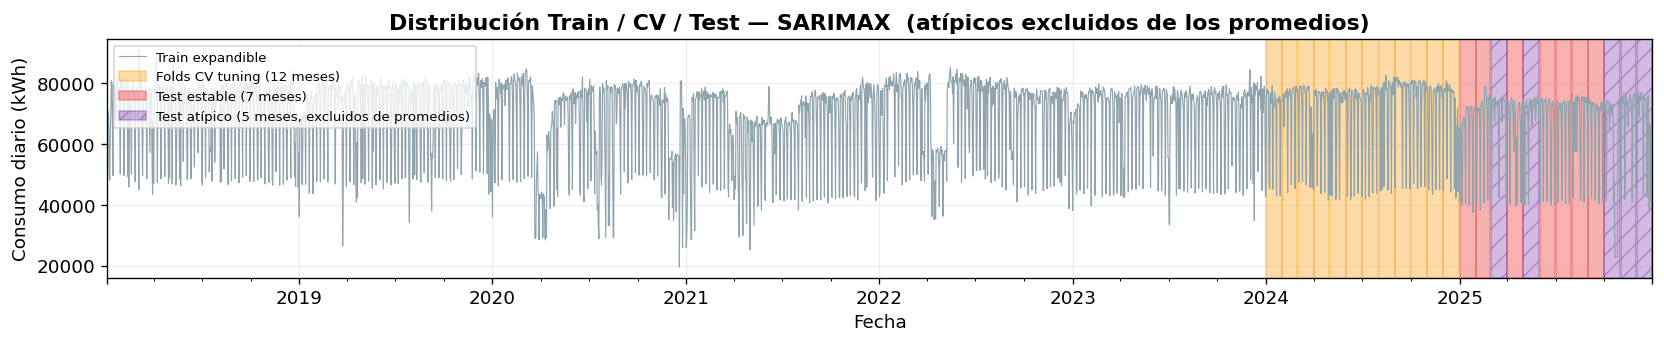

In [17]:
# ── Visualización del split (mismo esquema de color que RF) ──────────────────
fig, ax = plt.subplots(figsize=(14, 3))
df['Consumo'].plot(ax=ax, lw=0.7, color='#90A4AE', label='Train expandible')

for mes in CV_MONTHS:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color='#FFA726', alpha=0.40)
ax.axvspan(0, 0, color='#FFA726', alpha=0.40, label=f'Folds CV tuning ({N_CV_FOLDS} meses)')

for mes in STABLE_MONTHS:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color='#EF5350', alpha=0.45)
ax.axvspan(0, 0, color='#EF5350', alpha=0.45, label=f'Test estable ({len(STABLE_MONTHS)} meses)')

for mes in ATYP_IN_TEST:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color=COLOR_ATYPICAL, alpha=0.30, hatch='//')
ax.axvspan(0, 0, color=COLOR_ATYPICAL, alpha=0.30, hatch='//',
           label=f'Test atípico ({len(ATYP_IN_TEST)} meses, excluidos de promedios)')

ax.set_title('Distribución Train / CV / Test — SARIMAX  (atípicos excluidos de los promedios)',
             fontweight='bold')
ax.set_ylabel('Consumo diario (kWh)'); ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('split_overview_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 6. Funciones auxiliares

- `mask_invalid_lags`: anula `lag_k` cuando `k < día del mes` (no disponibles en producción).
- `compute_metrics`: MAE, RMSE, MAPE (%), R² (idénticas al resto de la familia).
- `fit_predict_rf`: imputa medias y ajusta un `RandomForestRegressor` (guarda el imputer para reuso en las bandas).
- `cv_score_rf`: walk-forward CV mensual sobre `CV_MONTHS`; retorna **media, std y mediana** del MAPE entre folds.



In [18]:
def compute_metrics(y_true, y_pred):
    """Calcula MAE, RMSE, MAPE y R² (idéntico al resto de la familia RF/SARIMAX)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MAPE (%)': round(mape, 4), 'R²': round(r2, 4)}


def fit_predict_sarimax(order, seasonal_order, y_tr, X_tr, y_te, X_te):
    """
    Ajusta un SARIMAX (pmdarima) con variables exógenas y retorna las predicciones sobre
    el período objetivo junto con el objeto modelo ajustado. Suprime warnings de convergencia.
    """
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            m = PmARIMA(order=order, seasonal_order=seasonal_order)
            m.fit(y_tr, X=X_tr)
            preds = m.predict(n_periods=len(y_te), X=X_te)
            return np.asarray(preds, dtype=float), m
        except Exception as e:
            print(f"    ⚠ Error en SARIMAX {order} / {seasonal_order}: {e}")
            return np.full(len(y_te), np.nan), None


def cv_score_sarimax(order, seasonal_order, cv_months, trial=None):
    """
    Walk-forward CV mensual dentro del train. Para cada mes en cv_months: entrena en todo lo
    anterior al mes (ventana expandible) y predice el mes completo. Retorna un dict con
    'mean' (criterio de selección), 'std', 'median', 'folds'.
    Si se pasa `trial` (Optuna), reporta la media acumulada del MAPE fold a fold y habilita el
    PRUNING (corta configuraciones que ya van claramente peor que la mediana, ahorrando folds).
    """
    mapes = []
    for step, mes in enumerate(cv_months):
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        y_tr, X_tr = tr[TARGET], tr[EXOG_COLS]
        y_v,  X_v  = val[TARGET], val[EXOG_COLS]
        preds, _ = fit_predict_sarimax(order, seasonal_order, y_tr, X_tr, y_v, X_v)
        if not np.all(np.isnan(preds)):
            mapes.append(compute_metrics(y_v.values, preds)['MAPE (%)'])
        else:
            mapes.append(999.0)
        # ── Pruning de Optuna: reporta media acumulada y corta si should_prune() ──
        if trial is not None:
            trial.report(float(np.mean(mapes)), step)
            if trial.should_prune():
                raise optuna.TrialPruned()
    mapes = np.array(mapes, dtype=float)
    if len(mapes) == 0:
        return {'mean': 999.0, 'std': 0.0, 'median': 999.0, 'folds': []}
    return {'mean': float(np.mean(mapes)),
            'std':  float(np.std(mapes, ddof=1)) if len(mapes) > 1 else 0.0,
            'median': float(np.median(mapes)),
            'folds': mapes.tolist()}


print("✓ Funciones auxiliares definidas.")



✓ Funciones auxiliares definidas.


 ## 7. Búsqueda guiada de hiperparámetros (warm-started desde el mejor SARIMAX conocido)

En vez de un grid search exhaustivo, partimos de la **estructura del mejor SARIMAX hallado hasta ahora** (`SARIMAX_BEST_KNOWN`: `order=(3,0,0)`, `seasonal_order=(1,0,2,7)`, MAPE CV ≈ 4.242 %) y exploramos solo su **vecindario**:

- El espacio de búsqueda está **centrado** en `SARIMAX_BEST_KNOWN` y cubre rangos discretos pequeños de `(p, d, q, P, D, Q)` — no se explota la grilla combinatoria completa.
- **Optuna (TPE)** para el muestreo bayesiano, con **`MedianPruner`**: reporta la media del MAPE fold a fold y **corta las configuraciones que ya van claramente peor** antes de gastar los 12 folds completos.
- El primer trial es **exactamente** `SARIMAX_BEST_KNOWN` (`enqueue_trial`) y está protegido del pruning (`n_startup_trials`), así el resultado **nunca es peor** que el punto de partida.
- El criterio sigue siendo el **MAPE medio de walk-forward CV**; se reportan también **std** y **mediana**.



In [20]:
# Espacio de búsqueda: vecindario discreto y pequeño alrededor de SARIMAX_BEST_KNOWN
# (p=3, d=0, q=0, P=1, D=0, Q=2). No se explora la grilla combinatoria completa.
SPACE = {
    'p': [1, 2, 3, 4],
    'd': [0, 1],
    'q': [0, 1, 2],
    'P': [0, 1, 2],
    'D': [0, 1],
    'Q': [1, 2, 3],
}

def _order_from(raw):
    return (int(raw['p']), int(raw['d']), int(raw['q'])), (int(raw['P']), int(raw['D']), int(raw['Q']), SEASONAL_M)

def _encode_known(best_known):
    o, so = best_known['order'], best_known['seasonal_order']
    return {'p': o[0], 'd': o[1], 'q': o[2], 'P': so[0], 'D': so[1], 'Q': so[2]}

tuning_rows = []
t0 = time.time()

if HAS_OPTUNA:
    def objective(trial):
        raw = {k: trial.suggest_categorical(k, v) for k, v in SPACE.items()}
        order, seasonal_order = _order_from(raw)
        trial.set_user_attr('order', order)
        trial.set_user_attr('seasonal_order', seasonal_order)
        cvs = cv_score_sarimax(order, seasonal_order, CV_MONTHS, trial=trial)
        trial.set_user_attr('cv_std', cvs['std'])
        trial.set_user_attr('cv_median', cvs['median'])
        return cvs['mean']

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3))
    study.enqueue_trial(_encode_known(BEST_KNOWN_SARIMAX))     # trial 1 = mejor conocido (warm-start)

    for it in tqdm(range(N_TRIALS), desc='SARIMAX Optuna'):
        study.optimize(objective, n_trials=1, catch=(Exception,))
        t = study.trials[-1]
        is_pruned = (t.state == optuna.trial.TrialState.PRUNED)
        order = t.user_attrs.get('order'); seasonal_order = t.user_attrs.get('seasonal_order')
        tuning_rows.append({'trial': it+1, 'cv_mape': t.value,
                            'cv_std': t.user_attrs.get('cv_std'),
                            'cv_median': t.user_attrs.get('cv_median'),
                            'pruned': bool(is_pruned),
                            'order': order, 'seasonal_order': seasonal_order})
        if (it+1) % 5 == 0 or (it+1) == N_TRIALS:
            best = study.best_value if study.best_trial else float('nan')
            vtxt = f"{t.value:.3f}%" if t.value is not None else "pruned "
            print(f"  trial {it+1:>3}/{N_TRIALS}  MAPE={vtxt}  mejor={best:.3f}%  t={time.time()-t0:.0f}s")

    bt = study.best_trial
    best_order = bt.user_attrs['order']; best_seasonal = bt.user_attrs['seasonal_order']
    best_params_sarimax = {'order': best_order, 'seasonal_order': best_seasonal}
    best_stats  = {'mean': bt.value, 'std': bt.user_attrs['cv_std'], 'median': bt.user_attrs['cv_median']}
    k0 = study.trials[0]
    known_stats = {'mean': k0.value, 'std': k0.user_attrs['cv_std'], 'median': k0.user_attrs['cv_median']}

else:
    def _sample_local():
        raw = {k: rng.choice(v) for k, v in SPACE.items()}
        return _order_from(raw)
    order0, seasonal0 = _order_from(_encode_known(BEST_KNOWN_SARIMAX))
    cands = [(order0, seasonal0)] + [_sample_local() for _ in range(N_TRIALS - 1)]
    best_params_sarimax, best_stats, known_stats = None, {'mean': np.inf}, None
    for it, (order, seasonal_order) in enumerate(tqdm(cands, desc='SARIMAX local')):
        cvs = cv_score_sarimax(order, seasonal_order, CV_MONTHS)
        tuning_rows.append({'trial': it+1, 'cv_mape': cvs['mean'],
                            'cv_std': cvs['std'], 'cv_median': cvs['median'],
                            'pruned': False, 'order': order, 'seasonal_order': seasonal_order})
        if it == 0:
            known_stats = {'mean': cvs['mean'], 'std': cvs['std'], 'median': cvs['median']}
        if cvs['mean'] < best_stats['mean']:
            best_stats = {'mean': cvs['mean'], 'std': cvs['std'], 'median': cvs['median']}
            best_params_sarimax = {'order': order, 'seasonal_order': seasonal_order}
        if (it+1) % 5 == 0 or (it+1) == len(cands):
            print(f"  trial {it+1:>3}/{len(cands)}  MAPE={cvs['mean']:.3f}%  "
                  f"mejor={best_stats['mean']:.3f}%  t={time.time()-t0:.0f}s")

tuning_df = pd.DataFrame(tuning_rows)
mejora = known_stats['mean'] - best_stats['mean']

print(f"\n{'='*62}")
print(f"  Búsqueda completada en {(time.time()-t0)/60:.1f} min")
print(f"  Best-known : MAPE CV = {known_stats['mean']:.3f}%  "
      f"(std {known_stats['std']:.3f} | mediana {known_stats['median']:.3f})")
print(f"  Tuneado    : MAPE CV = {best_stats['mean']:.3f}%  "
      f"(std {best_stats['std']:.3f} | mediana {best_stats['median']:.3f})")
print(f"  Mejora vs best-known: {mejora:+.3f} pp de MAPE")
print(f"  Params tuneados (final): {best_params_sarimax}")
print(f"{'='*62}")



SARIMAX Optuna:  33%|███▎      | 5/15 [11:02<23:26, 140.61s/it]

  trial   5/15  MAPE=4.490%  mejor=4.332%  t=663s


SARIMAX Optuna:  67%|██████▋   | 10/15 [12:57<03:19, 39.93s/it]

  trial  10/15  MAPE=4.803%  mejor=4.332%  t=778s


SARIMAX Optuna: 100%|██████████| 15/15 [18:17<00:00, 73.19s/it]

  trial  15/15  MAPE=4.831%  mejor=4.332%  t=1098s

  Búsqueda completada en 18.3 min
  Best-known : MAPE CV = 4.332%  (std 1.116 | mediana 4.290)
  Tuneado    : MAPE CV = 4.332%  (std 1.116 | mediana 4.290)
  Mejora vs best-known: +0.000 pp de MAPE
  Params tuneados (final): {'order': (3, 0, 0), 'seasonal_order': (1, 0, 2, 7)}


 ## 8. Convergencia de la búsqueda

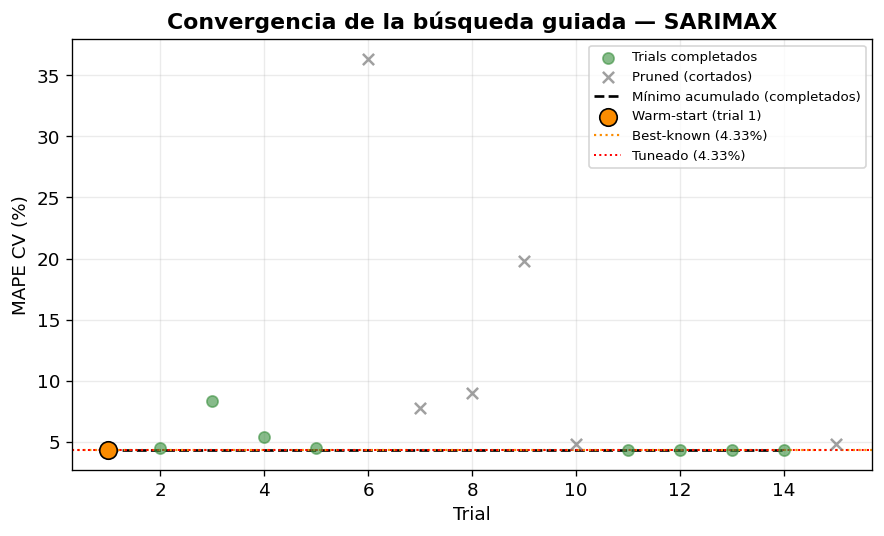

── Hiperparámetros ──
  Default : {'order': (2, 1, 2), 'seasonal_order': (1, 0, 1, 7)}
  Tuneado : {'order': (3, 0, 0), 'seasonal_order': (1, 0, 2, 7)}


In [21]:
# Los trials pruned conservan un MAPE parcial: se marcan por la columna 'pruned',
# y el mínimo acumulado se calcula SOLO con los trials completados (los elegibles como mejor).
tsort = tuning_df.sort_values('trial')
comp  = tsort[(~tsort['pruned'].fillna(False)) & tsort['cv_mape'].notna()].copy()
prun  = tsort[tsort['pruned'].fillna(False) & tsort['cv_mape'].notna()].copy()
comp['best_so_far'] = comp['cv_mape'].cummin()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(comp['trial'], comp['cv_mape'], color=SARIMAX_COLOR, alpha=0.6, s=45, zorder=3, label='Trials completados')
if len(prun):
    ax.scatter(prun['trial'], prun['cv_mape'], marker='x', color='gray',
               s=45, alpha=0.75, zorder=3, label='Pruned (cortados)')
ax.plot(comp['trial'], comp['best_so_far'], 'k--', lw=1.6, label='Mínimo acumulado (completados)')
w1 = tsort[tsort['trial'] == 1]
ax.scatter(w1['trial'], w1['cv_mape'], color='#FB8C00', s=110, zorder=5,
           edgecolor='k', label='Warm-start (trial 1)')
ax.axhline(known_stats['mean'], color='#FB8C00', lw=1.3, ls=':', label=f"Best-known ({known_stats['mean']:.2f}%)")
ax.axhline(best_stats['mean'],  color='red',     lw=1.2, ls=':', label=f"Tuneado ({best_stats['mean']:.2f}%)")
ax.set_xlabel('Trial'); ax.set_ylabel('MAPE CV (%)')
ax.set_title('Convergencia de la búsqueda guiada — SARIMAX', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('tuning_convergencia_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Hiperparámetros ──")
print(f"  Default : {DEFAULT_SARIMAX}")
print(f"  Tuneado : {best_params_sarimax}")



 ## 9. Evaluación final en test — Default vs Tuneado

Para cada mes de test se entrena SARIMAX con **todo el train anterior a ese mes** (ventana expandible), en dos variantes: **default** (`DEFAULT_SARIMAX`) y **tuneado** (`best_params_sarimax`).



In [22]:
def eval_variants():
    res = {}
    for mes in TEST_MONTHS:
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        train = df[df.index < cutoff]
        test  = df[(df.index >= cutoff) & (df.index <= end)]
        y_tr, X_tr = train[TARGET], train[EXOG_COLS]
        y_te, X_te = test[TARGET],  test[EXOG_COLS]
        res[mes] = {}
        for variant, params in [('default', DEFAULT_SARIMAX), ('tuned', best_params_sarimax)]:
            preds, model = fit_predict_sarimax(params['order'], params['seasonal_order'],
                                               y_tr, X_tr, y_te, X_te)
            metrics = (compute_metrics(y_te.values, preds) if not np.all(np.isnan(preds))
                      else {'MAE': np.nan, 'RMSE': np.nan, 'MAPE (%)': np.nan, 'R²': np.nan})
            res[mes][variant] = {'preds': preds, 'real': y_te.values, 'dates': y_te.index,
                                 'X_test': X_te, 'metrics': metrics, 'model': model}
        print(f"  ✓ {mes} evaluado (default + tuned)")
    return res

results = eval_variants()
print("\n✓ Evaluación completa.")



  ✓ 2025-01 evaluado (default + tuned)
  ✓ 2025-02 evaluado (default + tuned)
  ✓ 2025-03 evaluado (default + tuned)
  ✓ 2025-04 evaluado (default + tuned)
  ✓ 2025-05 evaluado (default + tuned)
  ✓ 2025-06 evaluado (default + tuned)
  ✓ 2025-07 evaluado (default + tuned)
  ✓ 2025-08 evaluado (default + tuned)
  ✓ 2025-09 evaluado (default + tuned)
  ✓ 2025-10 evaluado (default + tuned)
  ✓ 2025-11 evaluado (default + tuned)
  ✓ 2025-12 evaluado (default + tuned)

✓ Evaluación completa.


 ## 10. Predicción vs Real — Default vs Tuneado

Cada panel muestra el consumo real y las dos variantes de SARIMAX. Los meses atípicos van marcados con **⚠** y **no entran** en los promedios de las secciones siguientes.



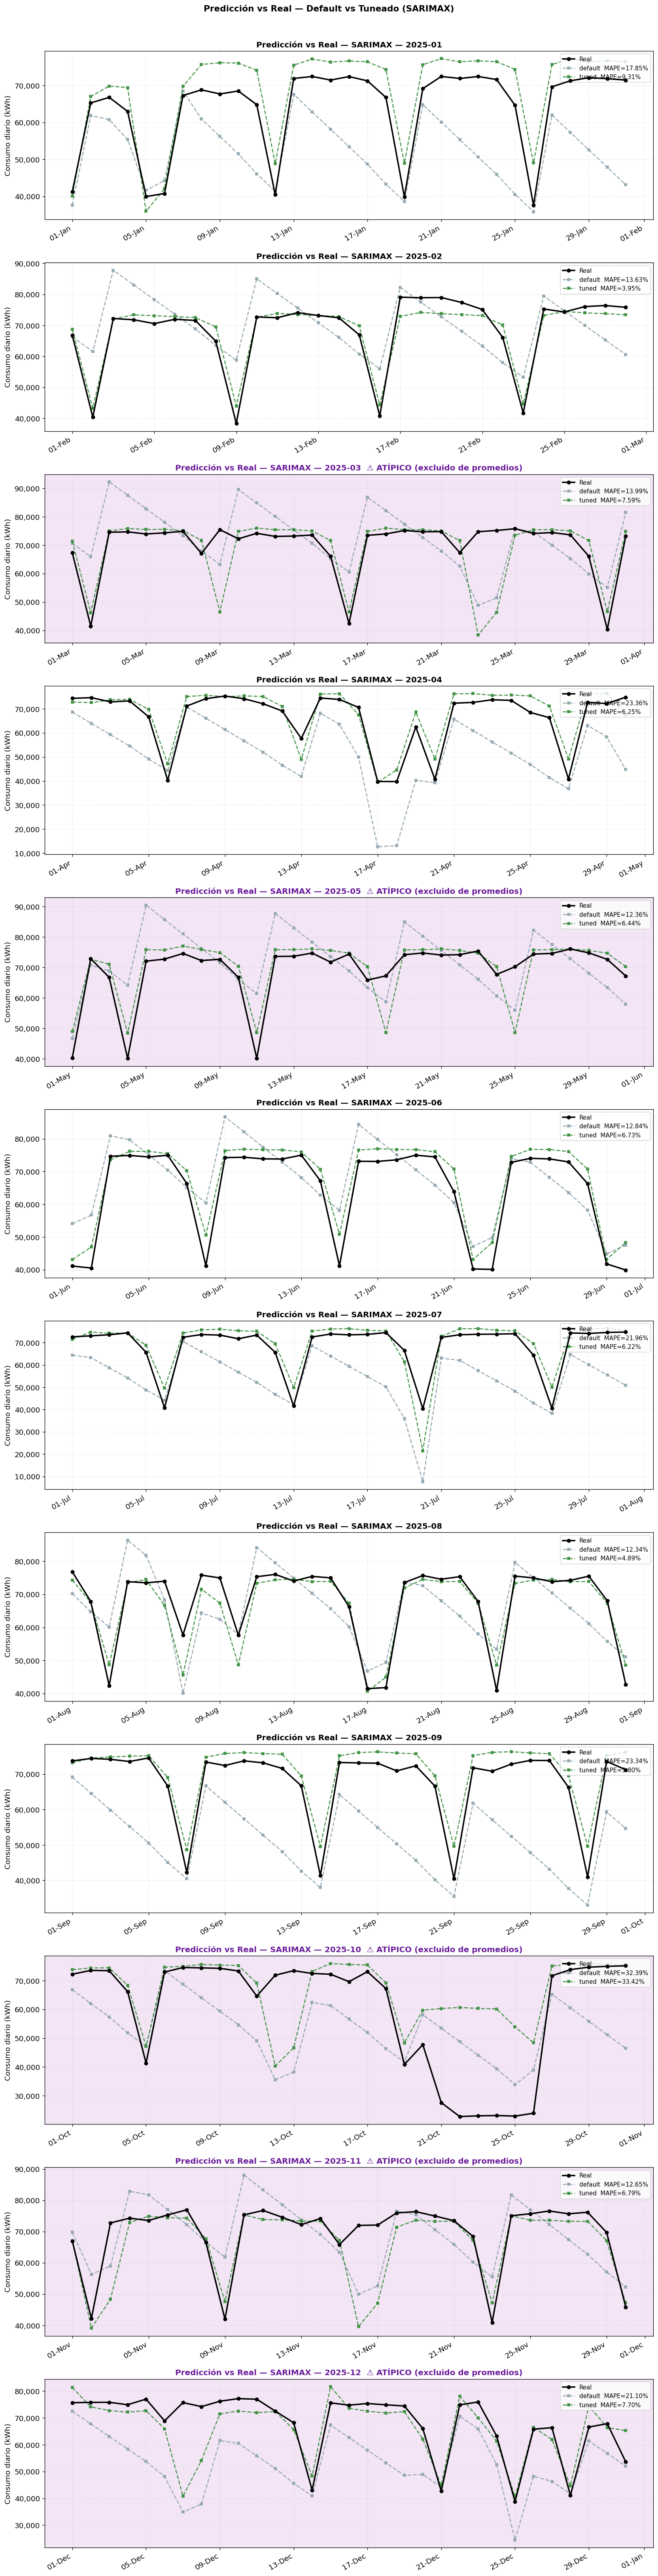

In [23]:
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5*n), sharex=False)
if n == 1: axes = [axes]

for ax, mes in zip(axes, PLOT_MONTHS):
    dates = results[mes]['tuned']['dates']
    real  = results[mes]['tuned']['real']
    ax.plot(dates, real, 'k-o', lw=2.2, ms=5, label='Real', zorder=6)
    for variant in VARIANTS:
        p    = results[mes][variant]['preds']
        mape = results[mes][variant]['metrics']['MAPE (%)']
        mape_txt = f"{mape:.2f}%" if not np.isnan(mape) else "error"
        ax.plot(dates, p, '--s', ms=4, lw=1.6, color=VCOLORS[variant], alpha=0.9,
                label=f"{variant}  MAPE={mape_txt}")
    tag = '  ⚠ ATÍPICO (excluido de promedios)' if is_atyp(mes) else ''
    ax.set_title(f'Predicción vs Real — SARIMAX — {mes}{tag}',
                 fontsize=12, fontweight='bold', color=(COLOR_ATYPICAL if is_atyp(mes) else 'black'))
    ax.set_ylabel('Consumo diario (kWh)')
    ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.25, ls='--')
    if is_atyp(mes): ax.set_facecolor('#F3E5F5')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Predicción vs Real — Default vs Tuneado (SARIMAX)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('pred_vs_real_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 11. Degradación del error con el horizonte — Default vs Tuneado



 Error absoluto por día dentro del mes (cómo crece a medida que avanza el horizonte de pronóstico).



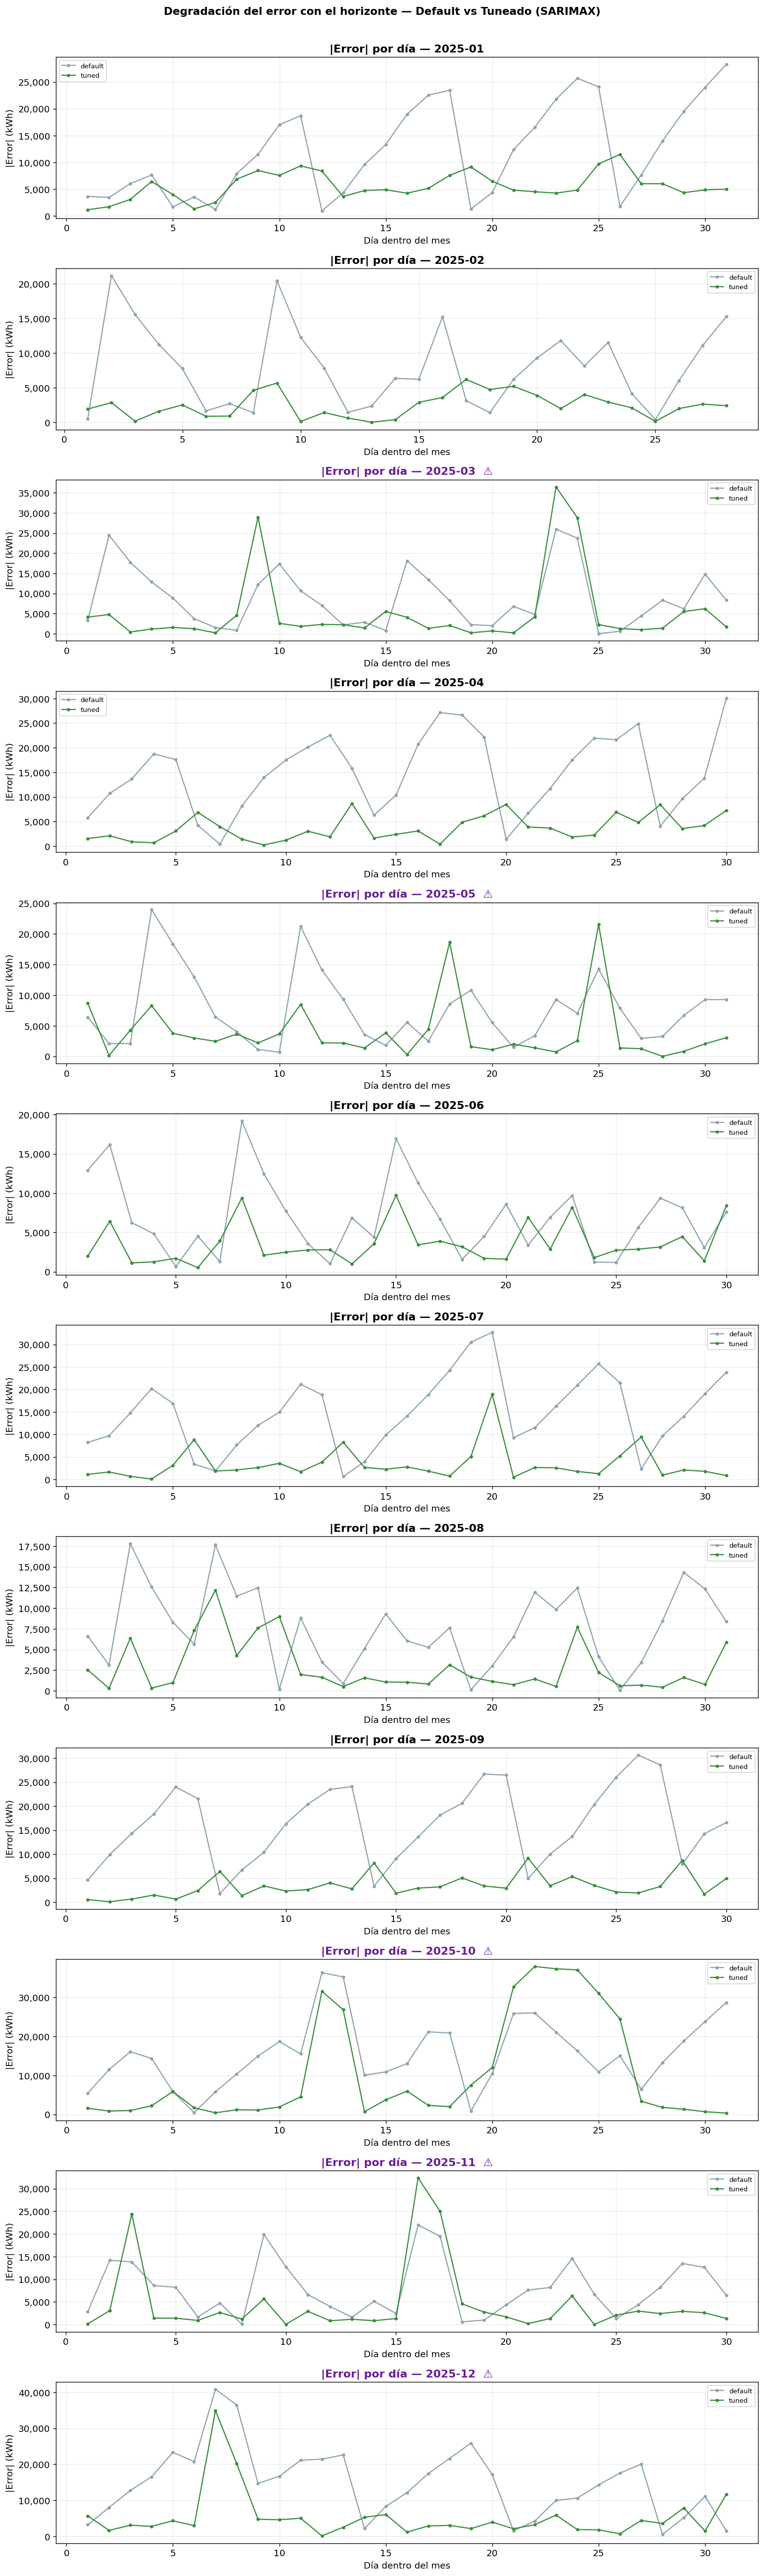

In [24]:
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(13, 3.6*n), sharex=False)
if n == 1: axes = [axes]

for ax, mes in zip(axes, PLOT_MONTHS):
    dates = results[mes]['tuned']['dates']
    dom   = np.array([d.day for d in dates])
    for variant in VARIANTS:
        r  = results[mes][variant]
        ae = np.abs(np.asarray(r['real'], float) - np.asarray(r['preds'], float))
        ax.plot(dom, ae, '-o', ms=3, lw=1.4, color=VCOLORS[variant], label=variant)
    tag = '  ⚠' if is_atyp(mes) else ''
    ax.set_title(f'|Error| por día — {mes}{tag}', fontweight='bold',
                 color=(COLOR_ATYPICAL if is_atyp(mes) else 'black'))
    ax.set_xlabel('Día dentro del mes'); ax.set_ylabel('|Error| (kWh)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Degradación del error con el horizonte — Default vs Tuneado (SARIMAX)',
             fontsize=13, fontweight='bold', y=1.003)
plt.tight_layout()
plt.savefig('error_horizonte_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 12. Tabla comparativa — Default vs Tuneado

In [25]:
def _avg_metrics(variant, meses):
    return pd.DataFrame([results[m][variant]['metrics'] for m in meses]).mean()

rows = []
for mes in TEST_MONTHS:
    for variant in VARIANTS:
        m = results[mes][variant]['metrics']
        rows.append({'Mes': mes, 'Atípico': is_atyp(mes), 'Variante': variant, **m})
metrics_df = pd.DataFrame(rows)

print("══ Métricas por mes (default vs tuned) ══")
print(metrics_df.to_string(index=False))

print("\n── Promedio sobre meses ESTABLES ──")
for variant in VARIANTS:
    a = _avg_metrics(variant, STABLE_MONTHS)
    print(f"  {variant:8s}: MAE={a['MAE']:,.0f}  RMSE={a['RMSE']:,.0f}  "
          f"MAPE={a['MAPE (%)']:.2f}%  R²={a['R²']:.4f}")



══ Métricas por mes (default vs tuned) ══
    Mes  Atípico Variante      MAE     RMSE  MAPE (%)      R²
2025-01    False  default 12149.03 14869.82   17.8452 -0.5485
2025-01    False    tuned  5553.69  6082.68    9.3052  0.7409
2025-02    False  default  7958.69  9870.75   13.6279  0.3308
2025-02    False    tuned  2447.66  3006.78    3.9510  0.9379
2025-03     True  default  8862.45 11526.74   13.9898 -0.4046
2025-03     True    tuned  5188.28 10215.19    7.5909 -0.1031
2025-04    False  default 14849.27 16843.20   23.3593 -0.9092
2025-04    False    tuned  3631.09  4403.31    6.2492  0.8695
2025-05     True  default  7603.65  9586.82   12.3618  0.0595
2025-05     True    tuned  3900.71  6191.37    6.4370  0.6077
2025-06    False  default  6919.69  8449.87   12.8373  0.6532
2025-06    False    tuned  3574.94  4381.29    6.7335  0.9068
2025-07    False  default 14803.09 16900.41   21.9616 -1.3976
2025-07    False    tuned  3318.51  4943.46    6.2185  0.7949
2025-08    False  default  7

 ## 13. Comparativa visual — MAPE por mes estable (Default vs Tuneado)

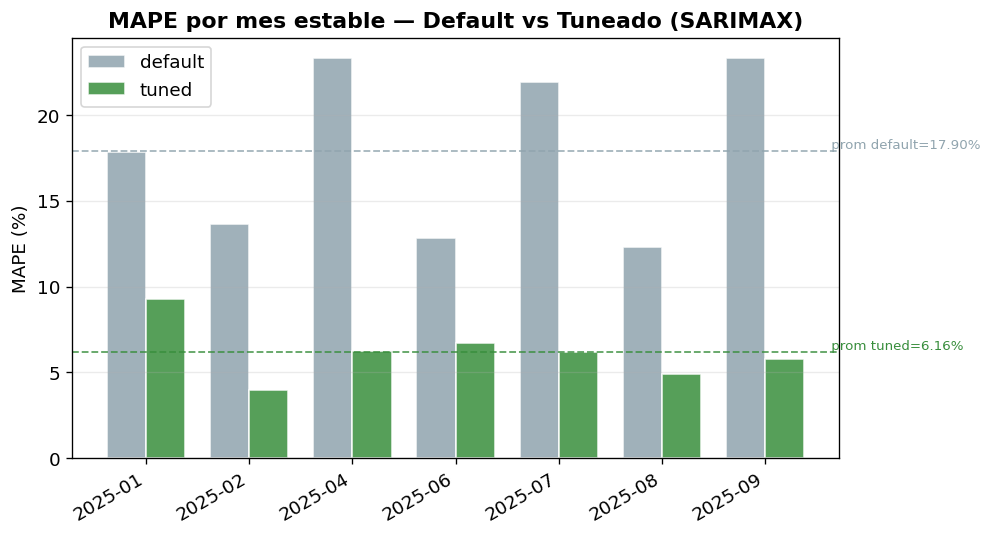

In [26]:
stable = STABLE_MONTHS
x = np.arange(len(stable)); w = 0.38
fig, ax = plt.subplots(figsize=(max(7, len(stable)*1.2), 4.6))
for k, variant in enumerate(VARIANTS):
    vals = [results[m][variant]['metrics']['MAPE (%)'] for m in stable]
    ax.bar(x + (k-0.5)*w, vals, w, color=VCOLORS[variant], alpha=0.85, label=variant, edgecolor='white')
    avg = float(np.nanmean(vals))
    ax.axhline(avg, color=VCOLORS[variant], ls='--', lw=1.1, alpha=0.8)
    ax.text(len(stable)-0.4, avg, f' prom {variant}={avg:.2f}%', va='bottom',
            fontsize=8, color=VCOLORS[variant])
ax.set_xticks(x); ax.set_xticklabels(stable, rotation=30, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por mes estable — Default vs Tuneado (SARIMAX)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('comparativa_mape_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 14. Heatmap MAPE — mes × variante

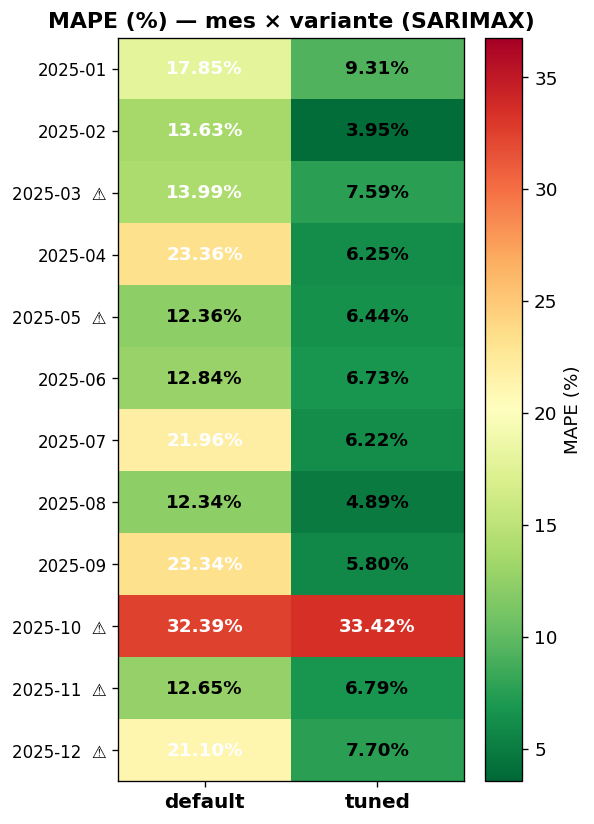

In [27]:
mat = np.array([[results[m][v]['metrics']['MAPE (%)'] for v in VARIANTS] for m in TEST_MONTHS])
fig, ax = plt.subplots(figsize=(5, max(4, len(TEST_MONTHS)*0.5 + 1)))
im = ax.imshow(mat, cmap='RdYlGn_r', aspect='auto',
               vmin=np.nanmin(mat)*0.9, vmax=np.nanmax(mat)*1.1)
ax.set_xticks(range(len(VARIANTS))); ax.set_xticklabels(VARIANTS, fontsize=12, fontweight='bold')
ylabels = [f'{m}  ⚠' if is_atyp(m) else m for m in TEST_MONTHS]
ax.set_yticks(range(len(TEST_MONTHS))); ax.set_yticklabels(ylabels, fontsize=10)
mean_val = np.nanmean(mat)
for i in range(len(TEST_MONTHS)):
    for j in range(len(VARIANTS)):
        v = mat[i, j]
        txt = f'{v:.2f}%' if not np.isnan(v) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center', fontweight='bold',
                fontsize=11, color='white' if (not np.isnan(v) and v > mean_val) else 'black')
plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_title('MAPE (%) — mes × variante (SARIMAX)', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_mape_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 15. Importancia de variables exógenas — SARIMAX tuneado (corregida)
- **A. Coeficientes exógenos por nombre**: se extraen del objeto `statsmodels` ajustado (`model.arima_res_.param_names` / `.params`) buscando **cada columna de `EXOG_COLS` por su nombre exacto**, no por posición. Se promedia el valor absoluto sobre los meses estables.

 - **B. Importancia por permutación (out-of-sample)**: para cada variable exógena, se baraja su columna en la ventana de test de cada mes estable, se vuelve a predecir con el **mismo modelo ya ajustado** (sin reentrenar) y se mide el aumento de MAPE. Se promedia sobre repeticiones y meses estables — mismo criterio (ΔMAPE) que usa el notebook de Random Forest.



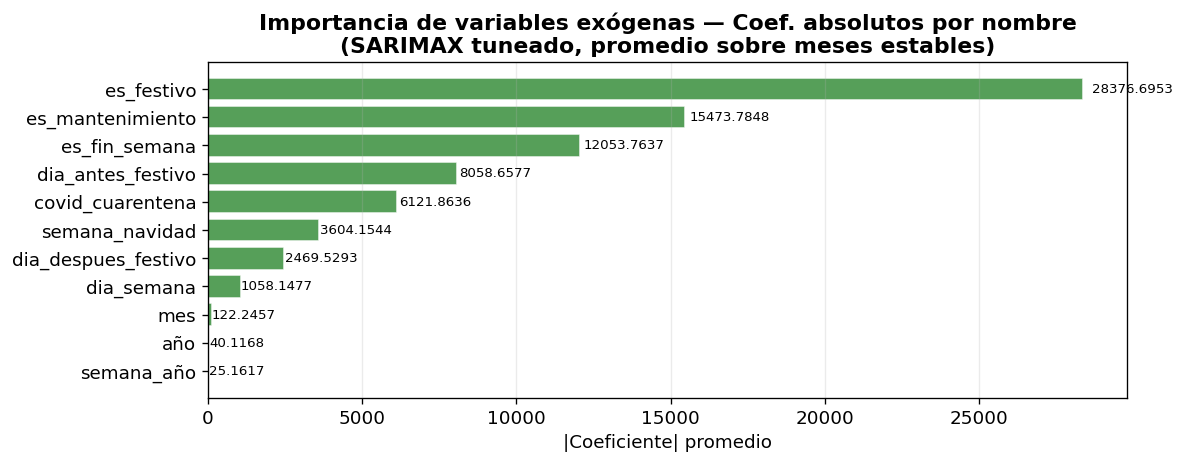

In [36]:
# ── A · Coeficientes exógenos extraídos por NOMBRE (no por posición) ─────────
def get_exog_coefs(model, exog_cols):
    """Extrae los coeficientes de las variables exógenas por NOMBRE desde el objeto
    statsmodels ajustado — corrige el supuesto roto de 'últimas N posiciones'."""
    if model is None or not hasattr(model, 'arima_res_'):
        return None
    try:
        res = model.arima_res_
        names = list(res.param_names)
        params = np.asarray(res.params)
        coefs = {}
        for col in exog_cols:
            if col in names:
                coefs[col] = float(params[names.index(col)])
        return coefs if coefs else None
    except Exception:
        return None

coef_rows = []
for mes in STABLE_MONTHS:
    model = results[mes]['tuned']['model']
    coefs = get_exog_coefs(model, EXOG_COLS)
    if coefs:
        coef_rows.append(pd.Series(coefs))

if coef_rows:
    avg_coef = pd.concat(coef_rows, axis=1).mean(axis=1).abs().nlargest(min(20, len(EXOG_COLS))).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(4, len(avg_coef)*0.35)))
    bars = ax.barh(avg_coef.index, avg_coef.values, color=SARIMAX_COLOR, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, avg_coef.values):
        ax.text(v*1.01, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
    ax.set_title('Importancia de variables exógenas — Coef. absolutos por nombre\n'
                 '(SARIMAX tuneado, promedio sobre meses estables)', fontweight='bold')
    ax.set_xlabel('|Coeficiente| promedio')
    ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.savefig('feature_importance_coef_sarimax.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    avg_coef = pd.Series(dtype=float)
    print("⚠ No se pudieron extraer coeficientes exógenos por nombre en ningún mes estable.")



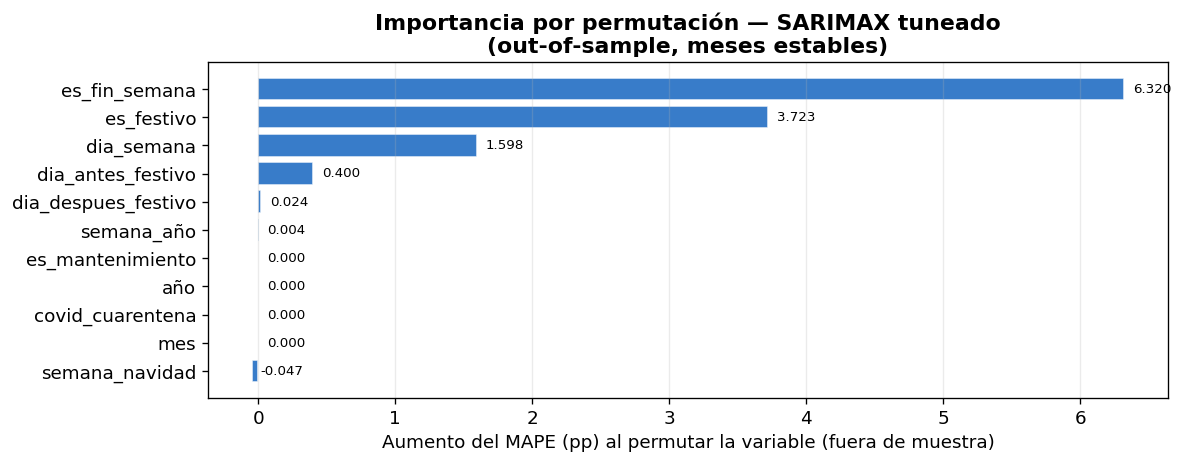

── Coeficientes vs Permutación (top-15 por permutación) ──
                     Coef. abs. (por nombre)  Permutación (ΔMAPE pp)
es_fin_semana                     12053.7637                  6.3205
es_festivo                        28376.6953                  3.7230
dia_semana                         1058.1477                  1.5983
dia_antes_festivo                  8058.6577                  0.4003
dia_despues_festivo                2469.5293                  0.0242
semana_año                           25.1617                  0.0037
mes                                 122.2457                  0.0000
año                                  40.1168                  0.0000
covid_cuarentena                   6121.8636                  0.0000
es_mantenimiento                  15473.7848                  0.0000
semana_navidad                     3604.1544                 -0.0473

→ Guardado: feature_importance_perm_sarimax.csv


In [37]:
# ── B · Importancia por permutación (out-of-sample, sin reentrenar) ──────────
def exog_permutation_importance(model, X_te, y_te, exog_cols, base_mape, n_repeats=10, seed=SEED):
    """Para cada variable, baraja su columna en X_te y mide cuánto empeora el MAPE al volver
    a predecir con el modelo YA ajustado (mismo criterio que la permutación de RF: no reentrena)."""
    rng_local = np.random.default_rng(seed)
    deltas = {}
    for col in exog_cols:
        increases = []
        for _ in range(n_repeats):
            X_perm = X_te.copy()
            X_perm[col] = rng_local.permutation(X_perm[col].to_numpy())
            try:
                preds_perm = np.asarray(model.predict(n_periods=len(y_te), X=X_perm), dtype=float)
                if np.all(np.isnan(preds_perm)):
                    continue
                mape_perm = compute_metrics(y_te, preds_perm)['MAPE (%)']
                increases.append(mape_perm - base_mape)
            except Exception:
                continue
        deltas[col] = float(np.mean(increases)) if increases else np.nan
    return deltas

perm_series = []
for mes in STABLE_MONTHS:
    r = results[mes]['tuned']
    model = r['model']
    if model is None:
        continue
    base_mape = r['metrics']['MAPE (%)']
    if np.isnan(base_mape):
        continue
    deltas = exog_permutation_importance(model, r['X_test'], r['real'], EXOG_COLS, base_mape,
                                         n_repeats=10, seed=SEED)
    perm_series.append(pd.Series(deltas))

if perm_series:
    perm_imp = pd.concat(perm_series, axis=1).mean(axis=1)   # ΔMAPE (pp) promedio por variable
    perm_top = perm_imp.dropna().nlargest(min(20, len(EXOG_COLS))).sort_values()

    fig, ax = plt.subplots(figsize=(10, max(4, len(perm_top)*0.35)))
    bars = ax.barh(perm_top.index, perm_top.values, color='#1565C0', alpha=0.85, edgecolor='white')
    _xmax = max(perm_top.values.max(), 1e-9)
    for bar, v in zip(bars, perm_top.values):
        ax.text(v + _xmax*0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
    ax.set_title('Importancia por permutación — SARIMAX tuneado\n(out-of-sample, meses estables)', fontweight='bold')
    ax.set_xlabel('Aumento del MAPE (pp) al permutar la variable (fuera de muestra)')
    ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.savefig('feature_importance_perm_sarimax.png', dpi=150, bbox_inches='tight')
    plt.show()

    if not avg_coef.empty:
        cmp_imp = (pd.DataFrame({'Coef. abs. (por nombre)': avg_coef.reindex(perm_imp.index),
                                 'Permutación (ΔMAPE pp)': perm_imp})
                     .sort_values('Permutación (ΔMAPE pp)', ascending=False).head(15))
        print("── Coeficientes vs Permutación (top-15 por permutación) ──")
        print(cmp_imp.round(4).to_string())

    perm_imp.sort_values(ascending=False).to_csv('feature_importance_perm_sarimax.csv', header=['perm_dMAPE_pp'])
    print("\n→ Guardado: feature_importance_perm_sarimax.csv")
else:
    perm_imp = pd.Series(dtype=float)
    print("⚠ No se pudo calcular importancia por permutación en ningún mes estable.")



 ## 16. APE promedio por horizonte — Default vs Tuneado (meses estables)

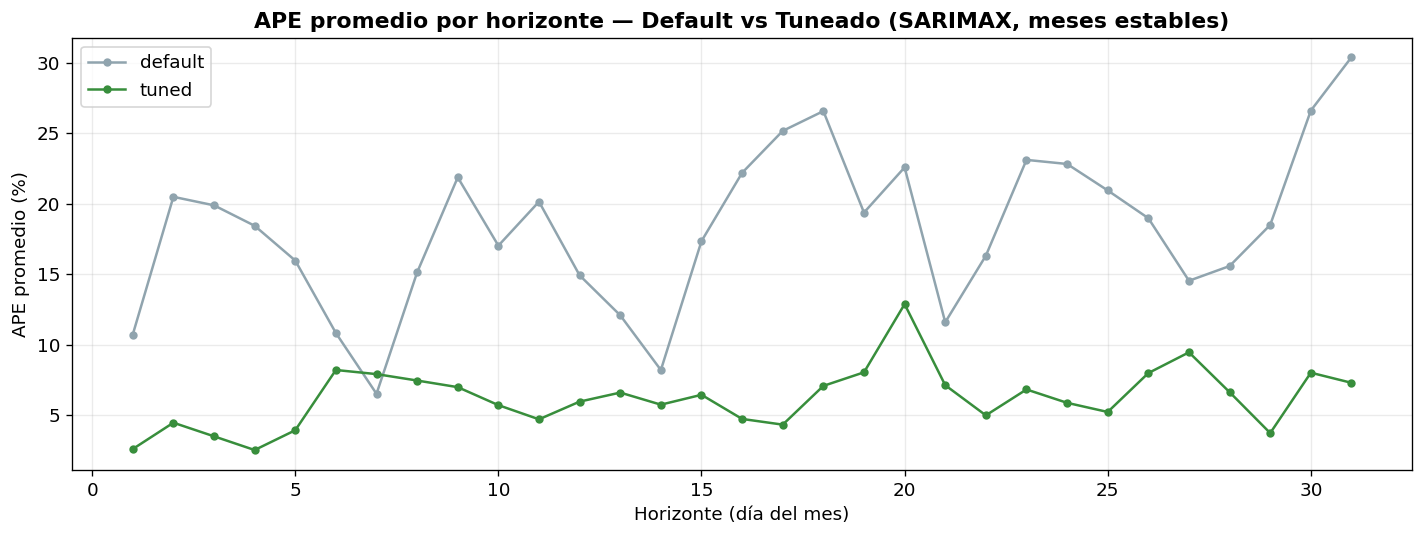

In [38]:
records = []
for mes in STABLE_MONTHS:
    for variant in VARIANTS:
        r = results[mes][variant]
        for d, rl, pr in zip(r['dates'], np.asarray(r['real'], float), np.asarray(r['preds'], float)):
            if rl != 0 and not np.isnan(pr):
                records.append({'dom': d.day, 'variant': variant, 'ape': abs(rl-pr)/rl*100})
ape_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 4.6))
for variant in VARIANTS:
    g = ape_df[ape_df['variant'] == variant].groupby('dom')['ape'].mean()
    ax.plot(g.index, g.values, '-o', ms=4, lw=1.5, color=VCOLORS[variant], label=variant)
ax.set_xlabel('Horizonte (día del mes)'); ax.set_ylabel('APE promedio (%)')
ax.set_title('APE promedio por horizonte — Default vs Tuneado (SARIMAX, meses estables)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('ape_horizonte_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



 ## 17. Comparación directa por mes — MAPE default vs tuned (con mejora)

In [39]:
rows = []
for mes in TEST_MONTHS:
    md_ = results[mes]['default']['metrics']['MAPE (%)']
    mt_ = results[mes]['tuned']['metrics']['MAPE (%)']
    rows.append({'Mes': mes, 'Atípico': is_atyp(mes),
                 'MAPE default': round(md_, 2) if not np.isnan(md_) else None,
                 'MAPE tuned': round(mt_, 2) if not np.isnan(mt_) else None,
                 'Δ': round(mt_ - md_, 2) if not (np.isnan(md_) or np.isnan(mt_)) else None,
                 '% mejora': round((md_ - mt_)/md_*100, 1) if md_ else None})
cmp_df = pd.DataFrame(rows)
print("══ MAPE por mes: default vs tuned ══")
print(cmp_df.to_string(index=False))

md_avg = np.nanmean([results[m]['default']['metrics']['MAPE (%)'] for m in STABLE_MONTHS])
mt_avg = np.nanmean([results[m]['tuned']['metrics']['MAPE (%)'] for m in STABLE_MONTHS])
print(f"\n(meses estables)  MAPE default = {md_avg:.2f}%   |   tuned = {mt_avg:.2f}%   "
      f"|   mejora = {(md_avg-mt_avg)/md_avg*100:+.1f}%")



══ MAPE por mes: default vs tuned ══
    Mes  Atípico  MAPE default  MAPE tuned      Δ  % mejora
2025-01    False         17.85        9.31  -8.54      47.9
2025-02    False         13.63        3.95  -9.68      71.0
2025-03     True         13.99        7.59  -6.40      45.7
2025-04    False         23.36        6.25 -17.11      73.2
2025-05     True         12.36        6.44  -5.92      47.9
2025-06    False         12.84        6.73  -6.10      47.5
2025-07    False         21.96        6.22 -15.74      71.7
2025-08    False         12.34        4.89  -7.44      60.3
2025-09    False         23.34        5.80 -17.53      75.1
2025-10     True         32.39       33.42   1.03      -3.2
2025-11     True         12.65        6.79  -5.86      46.3
2025-12     True         21.10        7.70 -13.40      63.5

(meses estables)  MAPE default = 17.90%   |   tuned = 6.16%   |   mejora = +65.6%


 ## 18. Intervalos — confianza del MAPE mensual y bandas de pronóstico

**A. Intervalo de confianza del MAPE mensual** (default y tuneado, con y sin atípicos): tratando el MAPE de cada mes como una muestra, respondemos *"¿con qué error saldrá un mes cualquiera?"* con dos rangos — **IC del MAPE medio** (incertidumbre sobre el promedio de largo plazo) e **IP de un mes nuevo** (dónde caerá el MAPE de un solo mes, más ancho). Mismas fórmulas t-Student que RF.

**B. Banda diaria alrededor del pronóstico tuneado** — al no ser SARIMAX un ensemble de árboles, se implementa **solo** el método portable: **conformal split condicionado por día de la semana** (misma función `weekday_conformal_bands` que en el notebook de RF). Se calibra sobre los residuos **fuera de muestra** recolectados en los folds de CV del modelo tuneado, y se reporta la **cobertura empírica** sobre los meses estables.



══════════════════════════════════════════════════════════════════════
  INTERVALOS DEL MAPE MENSUAL  (nivel 90%)
══════════════════════════════════════════════════════════════════════
Variante    Escenario  n  MAPE medio  MAPE mediana  std   min   max    IC90% media  IP90% un mes
 default Con atípicos 12       18.15         15.92 6.35 12.34 32.39 [14.86, 21.44] [6.28, 30.02]
 default Sin atípicos  7       17.90         17.85 5.01 12.34 23.36 [14.22, 21.58] [7.49, 28.31]
   tuned Con atípicos 12        8.76          6.59 7.89  3.95 33.42  [4.67, 12.85] [0.00, 23.50]
   tuned Sin atípicos  7        6.16          6.22 1.68  3.95  9.31   [4.93, 7.40]  [2.68, 9.65]

→ Guardado: intervalos_mape_sarimax.csv


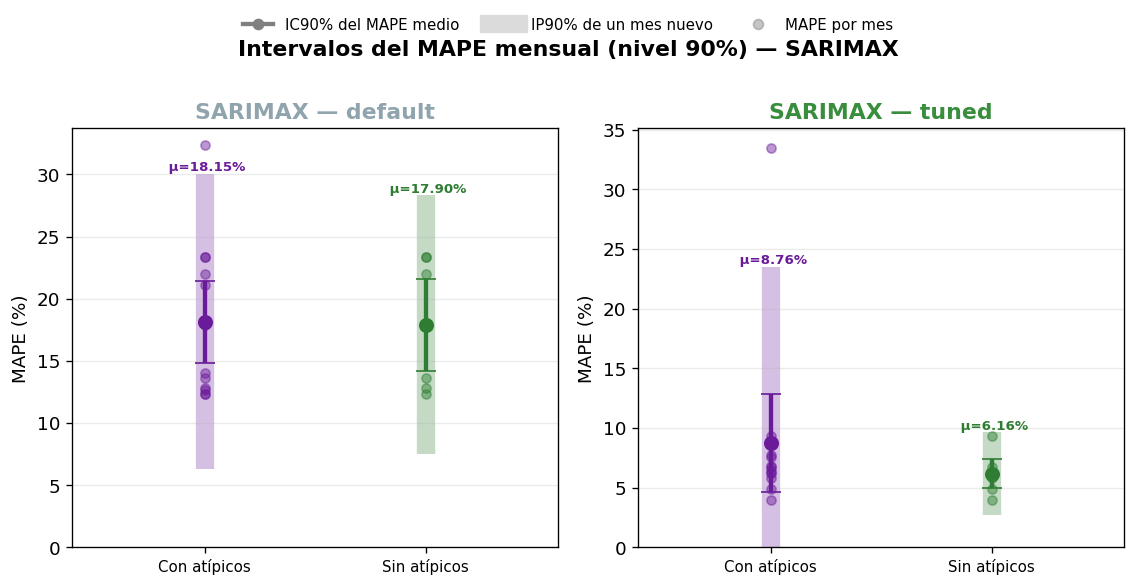

In [40]:
# ── A · Intervalo de confianza / predicción del MAPE mensual ─────────────────
Z   = CI_LEVEL
pct = int(round(Z * 100))

def _mape_por_mes(variant, meses):
    return np.array([results[m][variant]['metrics']['MAPE (%)'] for m in meses], dtype=float)

def _intervalos_mape(vals, level=Z):
    vals = vals[~np.isnan(vals)]
    n = len(vals)
    mean = float(np.mean(vals)) if n else np.nan
    med = float(np.median(vals)) if n else np.nan
    sd   = float(np.std(vals, ddof=1)) if n > 1 else 0.0
    out = {'n': n, 'media': mean, 'mediana': med, 'std': sd,
           'min': float(np.min(vals)) if n else np.nan, 'max': float(np.max(vals)) if n else np.nan,
           'ic_media': (mean, mean), 'ip_mes': (mean, mean), 'vals': vals}
    if n > 1:
        t = float(stats.t.ppf(0.5 + level/2, df=n-1)); se = sd/np.sqrt(n)
        out['ic_media'] = (mean - t*se,                  mean + t*se)
        out['ip_mes']   = (mean - t*sd*np.sqrt(1 + 1/n), mean + t*sd*np.sqrt(1 + 1/n))
    return out

_escenarios = {'Con atípicos': TEST_MONTHS, 'Sin atípicos': STABLE_MONTHS}
_store, _rows = {}, []
for variant in VARIANTS:
    _store[variant] = {}
    for esc, meses in _escenarios.items():
        vals = _mape_por_mes(variant, meses); s = _intervalos_mape(vals)
        _store[variant][esc] = s
        ic = (max(0.0, s['ic_media'][0]), s['ic_media'][1])
        ip = (max(0.0, s['ip_mes'][0]),   s['ip_mes'][1])
        _rows.append({'Variante': variant, 'Escenario': esc, 'n': s['n'],
                      'MAPE medio': round(s['media'], 2), 'MAPE mediana': round(s['mediana'], 2),
                      'std': round(s['std'], 2), 'min': round(s['min'], 2), 'max': round(s['max'], 2),
                      f'IC{pct}% media': f"[{ic[0]:.2f}, {ic[1]:.2f}]",
                      f'IP{pct}% un mes': f"[{ip[0]:.2f}, {ip[1]:.2f}]"})

ic_mape_df = pd.DataFrame(_rows)
print(f"{'═'*70}\n  INTERVALOS DEL MAPE MENSUAL  (nivel {pct}%)\n{'═'*70}")
print(ic_mape_df.to_string(index=False))
ic_mape_df.to_csv('intervalos_mape_sarimax.csv', index=False)
print("\n→ Guardado: intervalos_mape_sarimax.csv")

# Gráfica: IC del MAPE medio (barra fuerte) + IP de un mes (barra ancha clara), por variante
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.8*len(VARIANTS), 4.6), sharex=False)
if len(VARIANTS) == 1: axes = [axes]
offsets = {'Con atípicos': 0.0, 'Sin atípicos': 1.0}
ecolor  = {'Con atípicos': COLOR_ATYPICAL, 'Sin atípicos': '#2E7D32'}
for ax, variant in zip(axes, VARIANTS):
    for esc in _escenarios:
        s = _store[variant][esc]; x = offsets[esc]; m = s['media']
        if np.isnan(m):
            continue
        ic = (max(0.0, s['ic_media'][0]), s['ic_media'][1])
        ip = (max(0.0, s['ip_mes'][0]),   s['ip_mes'][1])
        ax.scatter(np.full(len(s['vals']), x), s['vals'], color=ecolor[esc], alpha=0.45, s=30, zorder=2)
        ax.errorbar(x, m, yerr=[[m-ip[0]], [ip[1]-m]], fmt='none', ecolor=ecolor[esc],
                    alpha=0.28, elinewidth=11, zorder=1)
        ax.errorbar(x, m, yerr=[[m-ic[0]], [ic[1]-m]], fmt='o', color=ecolor[esc],
                    ecolor=ecolor[esc], elinewidth=2.6, capsize=6, ms=8, zorder=3)
        ax.text(x, ip[1], f' μ={m:.2f}%', va='bottom', ha='center',
                fontsize=8, color=ecolor[esc], fontweight='bold')
    ax.set_xticks(list(offsets.values())); ax.set_xticklabels(list(offsets.keys()), fontsize=9)
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(bottom=0)
    ax.set_title(f'SARIMAX — {variant}', fontweight='bold', color=VCOLORS[variant])
    ax.set_ylabel('MAPE (%)'); ax.grid(True, axis='y', alpha=0.25)
handles = [Line2D([0],[0], color='gray', lw=2.6, marker='o', label=f'IC{pct}% del MAPE medio'),
           Line2D([0],[0], color='gray', lw=11, alpha=0.28, label=f'IP{pct}% de un mes nuevo'),
           Line2D([0],[0], color='gray', lw=0, marker='o', alpha=0.45, label='MAPE por mes')]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, 1.07), frameon=False)
plt.suptitle(f'Intervalos del MAPE mensual (nivel {pct}%) — SARIMAX', fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('intervalos_mape_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()



Recolectando residuos out-of-sample de walk-forward CV (SARIMAX tuneado)…
  n calibración = 366  (2024-01 … 2024-12, atípicos excluidos)


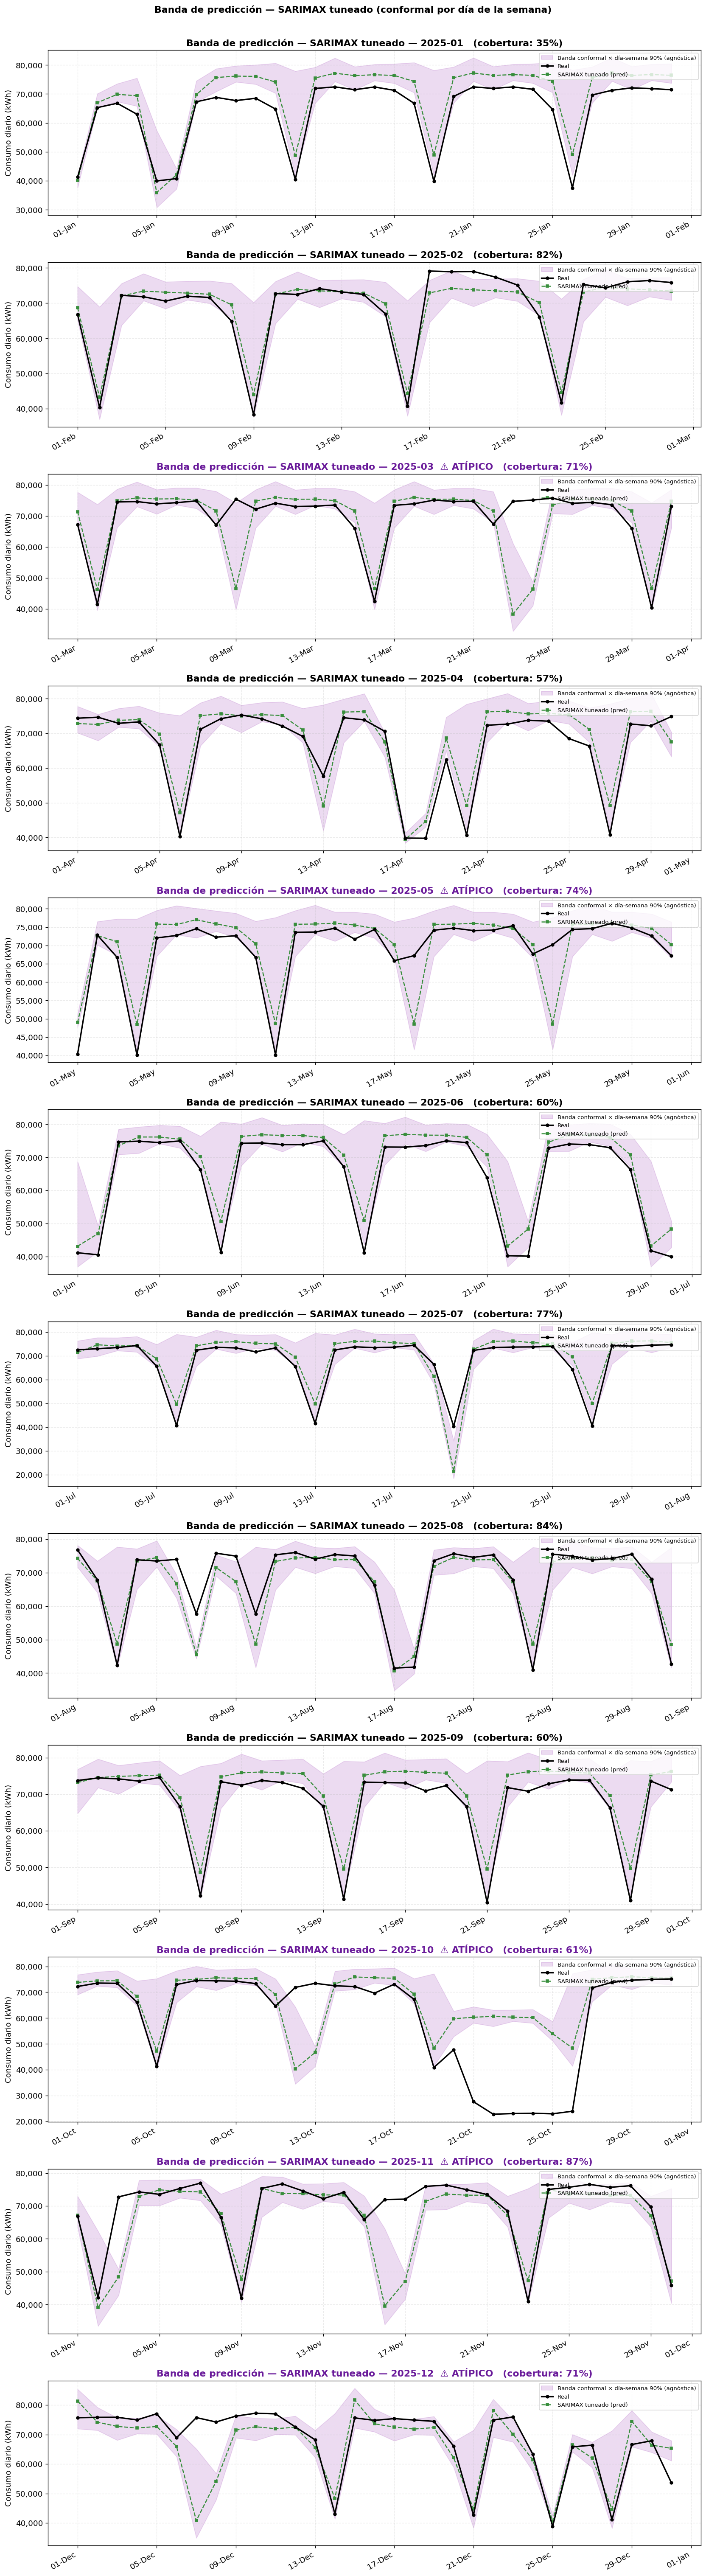


══ Cobertura empírica 90% (meses estables) ══
  Conformal × día-semana : cobertura media = 65.1%  (objetivo 90%)
  → Misma función que en RF (weekday_conformal_bands): comparación justa entre ambos modelos.


In [41]:
# ── B · Banda conformal condicionada por día de la semana (SARIMAX tuneado) ──
#     Misma función PORTABLE que en RF: recibe (fechas, real, pred) de calibración
#     y (fechas, pred) del target — así RF y SARIMAX se comparan con el mismo criterio.
PI = CI_LEVEL

def weekday_conformal_bands(cal_dates, cal_real, cal_pred,
                            target_dates, target_pred,
                            level=PI, mode='relative', min_group=15):
    a = 1 - level; ql, qh = a / 2, 1 - a / 2
    cal_real = np.asarray(cal_real, float); cal_pred = np.asarray(cal_pred, float)
    cal_wd = pd.DatetimeIndex(cal_dates).weekday.to_numpy()
    if mode == 'relative':
        ok = cal_pred != 0
        resid  = (cal_real[ok] - cal_pred[ok]) / cal_pred[ok]
        cal_wd = cal_wd[ok]
    else:  # 'absolute'
        resid = cal_real - cal_pred
    g_lo, g_hi = np.quantile(resid, ql), np.quantile(resid, qh)      # respaldo global
    lo_wd, hi_wd = {}, {}
    for w in range(7):
        r = resid[cal_wd == w]
        if len(r) >= min_group:
            lo_wd[w], hi_wd[w] = np.quantile(r, ql), np.quantile(r, qh)
        else:
            lo_wd[w], hi_wd[w] = g_lo, g_hi                          # weekday con pocos datos -> global
    tp  = np.asarray(target_pred, float)
    twd = pd.DatetimeIndex(target_dates).weekday.to_numpy()
    lo  = np.array([lo_wd[w] for w in twd]); hi = np.array([hi_wd[w] for w in twd])
    if mode == 'relative':
        return tp * (1 + lo), tp * (1 + hi)
    return tp + lo, tp + hi

# Calibración: residuos out-of-sample del SARIMAX tuneado sobre los folds CV (un año) ──
def collect_cv_oos_sarimax(params, cv_months):
    D, R, P = [], [], []
    for mes in cv_months:
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        y_tr, X_tr = tr[TARGET], tr[EXOG_COLS]
        y_v,  X_v  = val[TARGET], val[EXOG_COLS]
        preds, _ = fit_predict_sarimax(params['order'], params['seasonal_order'], y_tr, X_tr, y_v, X_v)
        if not np.all(np.isnan(preds)):
            D.extend(list(val.index)); R.extend(list(y_v.values)); P.extend(list(np.asarray(preds, float)))
    return pd.DatetimeIndex(D), np.array(R, float), np.array(P, float)

CAL_MODE = 'relative'   # 'relative' (multiplicativo, se adapta al nivel) | 'absolute' (aditivo)
print("Recolectando residuos out-of-sample de walk-forward CV (SARIMAX tuneado)…")
cal_D, cal_R, cal_P = collect_cv_oos_sarimax(best_params_sarimax, CV_MONTHS)
print(f"  n calibración = {len(cal_R)}  ({CV_MONTHS[0]} … {CV_MONTHS[-1]}, atípicos excluidos)")

def banda_weekday(mes):
    rr = results[mes]['tuned']
    return weekday_conformal_bands(cal_D, cal_R, cal_P, rr['dates'], rr['preds'],
                                   level=PI, mode=CAL_MODE)

_band_cache = {}
def get_band(mes):
    if mes not in _band_cache:
        _band_cache[mes] = banda_weekday(mes)
    return _band_cache[mes]

# ── Gráfica: banda conformal por mes ──────────────────────────────────────────
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.2*n), sharex=False)
if n == 1: axes = [axes]
for ax, mes in zip(axes, PLOT_MONTHS):
    rr = results[mes]['tuned']
    dates, real, pred = rr['dates'], rr['real'], np.asarray(rr['preds'], float)
    lo_w, hi_w = get_band(mes)
    ax.fill_between(dates, lo_w, hi_w, color='#8E24AA', alpha=0.16,
                    label=f'Banda conformal × día-semana {int(PI*100)}% (agnóstica)')
    ax.plot(dates, real, 'k-o', lw=2, ms=4, label='Real', zorder=6)
    ax.plot(dates, pred, '--s', ms=3.5, lw=1.5, color=SARIMAX_COLOR, label='SARIMAX tuneado (pred)', zorder=5)
    cov_w = float(np.mean((real >= lo_w) & (real <= hi_w))) * 100
    tag = '  ⚠ ATÍPICO' if is_atyp(mes) else ''
    ax.set_title(f'Banda de predicción — SARIMAX tuneado — {mes}{tag}   (cobertura: {cov_w:.0f}%)',
                 fontweight='bold', color=(COLOR_ATYPICAL if is_atyp(mes) else 'black'))
    ax.set_ylabel('Consumo diario (kWh)'); ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25, ls='--')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Banda de predicción — SARIMAX tuneado (conformal por día de la semana)',
             fontweight='bold', y=1.003)
plt.tight_layout()
plt.savefig('bandas_prediccion_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cobertura empírica sobre meses estables (objetivo = nivel nominal) ────────
print(f"\n══ Cobertura empírica {int(PI*100)}% (meses estables) ══")
cov_w_all = []
for mes in STABLE_MONTHS:
    real = results[mes]['tuned']['real']
    lw, hw = get_band(mes)
    cov_w_all.append(float(np.mean((real >= lw) & (real <= hw))))
if cov_w_all:
    print(f"  Conformal × día-semana : cobertura media = {np.mean(cov_w_all)*100:.1f}%  (objetivo {int(PI*100)}%)")
    print("  → Misma función que en RF (weekday_conformal_bands): comparación justa entre ambos modelos.")
else:
    print("  (sin meses estables)")



 ## 19. Resumen sobre meses estables y exportación

In [42]:
# ── Resumen (solo meses estables) ────────────────────────────────────────────
summary_rows = []
for variant in VARIANTS:
    a = _avg_metrics(variant, STABLE_MONTHS)
    summary_rows.append({'Variante': variant, 'MAE': round(a['MAE'], 0), 'RMSE': round(a['RMSE'], 0),
                         'MAPE (%)': round(a['MAPE (%)'], 2), 'R²': round(a['R²'], 4)})
summary_stable = pd.DataFrame(summary_rows).set_index('Variante')
d_mape = summary_stable.loc['default', 'MAPE (%)']; t_mape = summary_stable.loc['tuned', 'MAPE (%)']
print("══ RESUMEN — MESES ESTABLES (SARIMAX) ══")
print(summary_stable.to_string())
print(f"\n→ MAPE default = {d_mape:.2f}%  →  tuneado = {t_mape:.2f}%  "
      f"(mejora {(d_mape-t_mape)/d_mape*100:+.1f}%)")

# ── Predicciones día a día (default + tuned, con flag de atípico) ─────────────
all_rows = []
for mes in TEST_MONTHS:
    for variant in VARIANTS:
        r = results[mes][variant]
        for date, pred, real_v in zip(r['dates'], r['preds'], r['real']):
            pred = float(pred)
            ape = round(abs(real_v - pred)/real_v*100, 4) if (real_v != 0 and not np.isnan(pred)) else None
            all_rows.append({'Fecha': date.date(), 'Mes': mes, 'Atipico': is_atyp(mes),
                             'Variante': variant, 'Real': real_v,
                             'Prediccion': round(pred, 2) if not np.isnan(pred) else None,
                             'AbsError': round(abs(real_v - pred), 2) if not np.isnan(pred) else None,
                             'APE (%)': ape})
preds_df = pd.DataFrame(all_rows)
preds_df.to_csv('predicciones_sarimax.csv', index=False)

# ── Métricas completas + tuning + params ─────────────────────────────────────
metrics_df.to_csv('metricas_sarimax.csv', index=False)
tuning_df.to_csv('tuning_sarimax.csv', index=False)
summary_stable.to_csv('resumen_meses_estables_sarimax.csv')
with open('best_params_sarimax.json', 'w') as f:
    json.dump({'default': DEFAULT_SARIMAX, 'tuned': best_params_sarimax,
               'best_known': BEST_KNOWN_SARIMAX,
               'cv_known': known_stats, 'cv_tuned': best_stats}, f, indent=2, default=str)

print("\nArchivos exportados:")
print("  predicciones_sarimax.csv             — predicciones día a día (default + tuned)")
print("  metricas_sarimax.csv                 — MAE/RMSE/MAPE/R² por mes y variante")
print("  tuning_sarimax.csv                   — historial de la búsqueda guiada")
print("  intervalos_mape_sarimax.csv          — intervalos del MAPE mensual")
print("  feature_importance_perm_sarimax.csv  — importancia por permutación (out-of-sample)")
print("  resumen_meses_estables_sarimax.csv   — resumen promediado sobre meses estables")
print("  best_params_sarimax.json             — default / tuned / best-known + scores CV")
print(f"\n{preds_df.head(8).to_string(index=False)}")

══ RESUMEN — MESES ESTABLES (SARIMAX) ══
              MAE     RMSE  MAPE (%)      R²
Variante                                    
default   11511.0  13437.0     17.90 -0.4674
tuned      3531.0   4435.0      6.16  0.8556

→ MAPE default = 17.90%  →  tuneado = 6.16%  (mejora +65.6%)

Archivos exportados:
  predicciones_sarimax.csv             — predicciones día a día (default + tuned)
  metricas_sarimax.csv                 — MAE/RMSE/MAPE/R² por mes y variante
  tuning_sarimax.csv                   — historial de la búsqueda guiada
  intervalos_mape_sarimax.csv          — intervalos del MAPE mensual
  feature_importance_perm_sarimax.csv  — importancia por permutación (out-of-sample)
  resumen_meses_estables_sarimax.csv   — resumen promediado sobre meses estables
  best_params_sarimax.json             — default / tuned / best-known + scores CV

     Fecha     Mes  Atipico Variante    Real  Prediccion  AbsError  APE (%)
2025-01-01 2025-01    False  default 41255.5    37613.61   3641.89   